# 什么是RL

强化学习尚未广泛运用于商业，却是机器学习的基础

寻找函数$\pi:s \to a$（由状态到动作）

拿直升机举例，如果我们用传统的监督学习，我们就是要通过状态s（输入）得到动作a（输出）。实际上这非常的困难，因为没有一个完完全全标准的动作，导致你几乎无法获得一个不错数据集（同时，决策会很难）

强化学习的目的是最大化一个价值函数(value Function)，做对了会得到奖励，反之则是负奖励。模型要做的就是最大化价值函数

**强化学习学的是做什么，而不是怎么做**，因为奖励只来源于结果

# The Return in RL

$$G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$或者到终止时刻$T$$$G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$$

其中$\gamma \in [0, 1]$是折扣因子，代表你对未来的重视程度<br>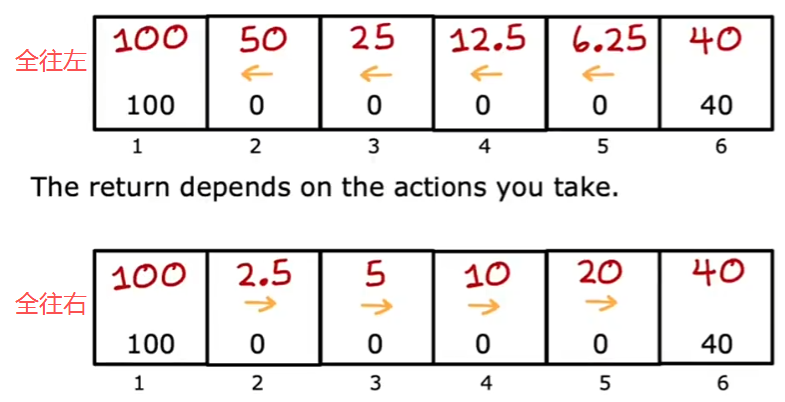

根据公式你会发现，如果出现负奖励，模型会尽可能将其推到未来（减小负奖励的影响）

# The Policies in RL

上面的$G_t$也是value，Policy就是模型根据当前状态做出动作的函数$\pi$，我们的目标就是得到$\pi^*$使得value最大化<br>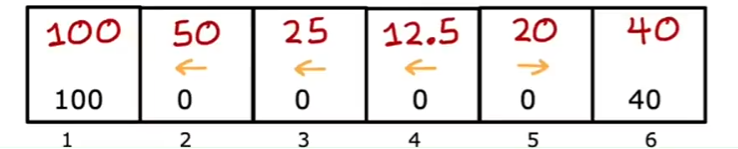

# 关键概念回顾

## MDP

马尔科夫性：$P\!\left(X_{t+1}\mid X_t,X_{t-1},\ldots,X_0\right)=P\!\left(X_{t+1}\mid X_t\right)$，也即对未来只取决于当下而非过去

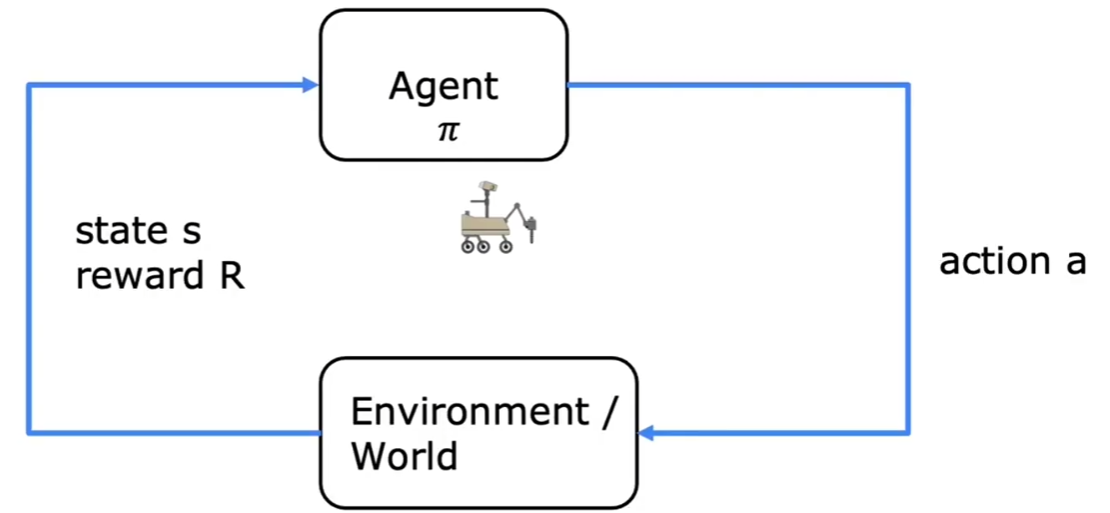

# state-action价值函数(Q-Function)的定义

$Q(s,a)=G_t$ if you start in 𝑠, take action 𝑎, then behave optimally.（准确来说，这描述的是$Q^*$（最优的Q））

# Bellman Equation

$Q(s,a)=R(s)+\gamma max_{a'}Q(s',a')$<br>
$s'$是后继状态

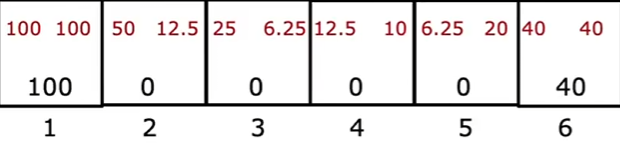<br>
举个例子：算$Q(2,right)=0+\gamma max[Q(3,left),Q(3,right)]$显然最大的$Q(3,left)$所以计算出了$Q(2,right)=12.5$

从公式中可以看出，价值有两个部分：当前奖励+未来的奖励

# 随机环境

除了本来的策略可以输出a改变s以外，还有环境导致的s改变（随机的）

$Q(s,a)=R(s)+\gamma \mathbb{E}[max_{a'}Q(s',a')]$

例如在火星车的例子中，可能有概率反方向移动

# 示例：连续状态空间应用

现实不像例子中六个格子的位置，而是连续的

如果对于一个卡车，他的状态可能很多（位置，速度，角速度...），而且其分量的值都是连续的

# 着陆月球

其动作空间有四个action:
1. nothing
2. left
3. main
4. right

$s=
\begin{bmatrix}
x\\
y\\
\dot{x}\\
\dot{y}\\
\theta\\
\dot{\theta}\\
l\\
r
\end{bmatrix}$，这是一个月球着陆器的状态（位置，速度，角度，左右腿是否着地）

奖励函数：<br>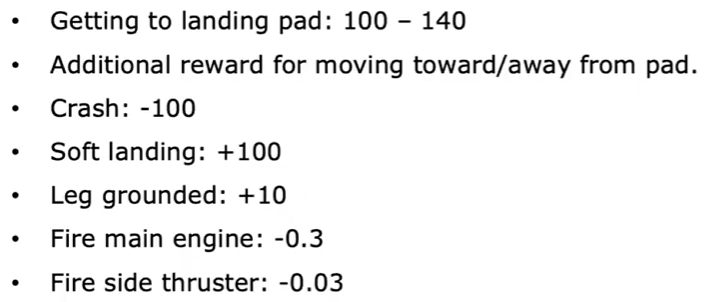

# 学习Q-function

## 深度强化学习

 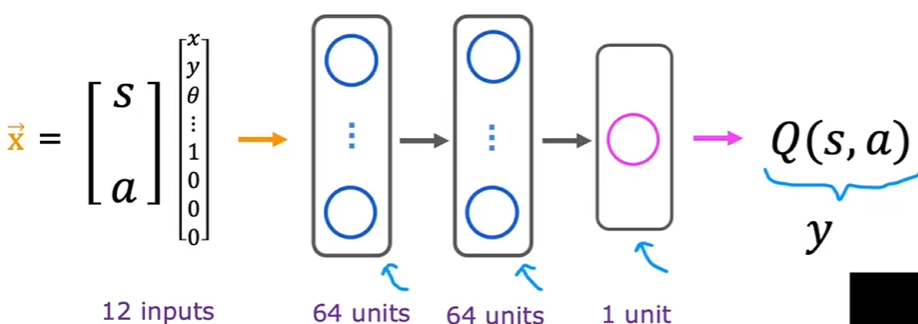<br>
 然后对于任意的state，都可以算出每个动作的Q，Policy就是选择最大化Q的a

利用Bellman-Equation：$Q(s,a)=R(s)+\gamma max_{a'}Q(s',a')$我们需要得到什么？<br>
$f_{W,B}(x)\approx y$这里x就是状态+动作，y就是我们需要预测的值（这里f就是Q的神经网络近似）

对于每一次决策，都会产生元组(tuple)：$(s^{(k)},a^{(k)},R(s^{(k)}),s'^{(k)})$前两个就是x，后两个就是用于计算y

会发现，如果我们要计算y，我们就要知道Q，但是为了知道Q我们需要先计算y（循环，，，）<br>
所以我们先随机一个Q

## 训练算法(DQN)

1. 先随机初始化神经网络权重（随机一个Q）
2. 重复：
   1. 在环境中随便做一些动作，获得tuple
   2. 储存最近的1W个tuples（称为Replay Buffer）
   3. 训练神经网络
      1. 创建(x,y)对，$x=(s,a)\quad y=R(s)+\gamma max_{a'}Q(s',a')$（这里的Q就是正在训练的神经网络）
      2. 训练$Q_{new}$使得$Q_{new}(s,a)\approx y$
   4. Set $Q=Q_{new}$

# 算法改进

## 神经网络结构

将输出层改为动作空间的维数即可

例如将月球着陆器的输出层的一个神经元改为四个：分别对应四个动作

## $\varepsilon$-贪婪策略

$\varepsilon$即为探索率，两种情况：
1. 始终选择“最优”a，$\arg_a maxQ(s,a)$
2. $1-\varepsilon$的概率选择“最优”a，$\varepsilon$选择随机的a

这样可以防止模型一条路走到黑，让他尝试一些不同的方法。例如，在本例中，模型可能永远都发现不了启动主引擎的作用（减速，用于更好的调整，虽然会有惩罚）

一个技巧：$\varepsilon$开始很高，最后逐渐降低

强化学习对超参数十分敏感，$\varepsilon$选的有问题可能导致十倍的训练耗时

## mini-batch & soft updates

### mini-batch

先看看监督学习：假设我们有100M的数据，这意味着我们每次梯度下降，就要计算100M个数平方的和

mini-batch就是每次只取数据子集，用来梯度下降<br>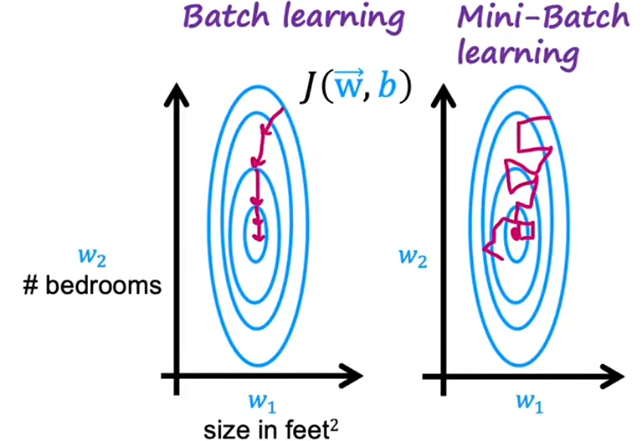

之前的强化学习中需要1W个样本，我们同理，每次取1000训练，虽然嘈杂但是速度更快

### soft updates

DQN中学习算法的一个步骤：Set $Q=Q_{new}$，有概率我们在训练的时候，新的神经网络反而可能劣于旧的，为了防止这种情况，需要soft updates

$Q = \varepsilon Q + (1-\varepsilon)Q_{new}$